<a href="https://colab.research.google.com/github/Younesmoussaoui/Application-Project--Q--learning/blob/main/Lead_Time_SVFF_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data visualisation & Data inderstending

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
## Lire le fichier sous forme d'excel .
DS = pd.read_excel('/content/drive/MyDrive/données 2.xlsx', sheet_name=['entete  commande', 'ligne commande','ligne commande','ligne BRF'])
## Lire la table '' entete commande ''
DSEC= DS['entete  commande']
## Lire la table '' ligne commande ''
DSEC1= DS['ligne commande']
### Data visualisation de la table '' entete commande ''
## nombres des ligne & colonnes
print(DSEC.shape)
print(DSEC.columns)
## types de chauqe colonne
print(DSEC.dtypes)
## Calcule du pourcentage des valeurs manquantes de chaque colonne
DSEC.isnull().sum()
percent_missing = DSEC.isnull().sum() * 100 / len(DSEC)
null_percentage_sorted = percent_missing.sort_values(ascending=False)
print(percent_missing)

#*  DSEC = C'est la table de l'entete commande qui contient des détails sur le fournisseur en particulier et inclura des détails relatifs au compte qui sera facturé et aux détails comptables.
#*  DSEC1 = C'est la table de ligne commande qui contient des détails sur les articles d’inventaire spécifiques ( disponibles dans l’en-tête)
#*  En gros l’entête de commande contient des informations générales sur la commande, tandis que la ligne de commande contient des informations spécifiques sur les articles commandés
#   donc pour une bonne interprétation et bonne analyse on voit que la meilleure solution est de fusioner les deux tables pour exploiter le maximum d'informations " features "

(3265, 41)
Index(['CMD_ALIAS', 'CMD_NUM', 'FOU_CODE', 'CTR_NUM', 'CMD_DATE', 'CMD_SUIVI',
       'CMD_CONSULTATION', 'CMD_REFERENCE', 'CMD_FACTURE', 'CMD_REGLEMENT',
       'CMD_DELAIACHAT', 'CMD_EMBALLAGE', 'CMD_MODLIEULIV', 'CMD_CLAUSE',
       'CMD_OBSERVATION', 'CMD_TRANSPORT', 'CMD_DATEPOSIT', 'CMD_TAXE',
       'CMD_VALTAXE', 'CMD_INC', 'CMD_MONNAIE', 'CMD_PAI_TYPE', 'CMD_RETENUE',
       'CMD_REMISE', 'CMD_TIMBRE', 'CMD_AVENANT', 'CMD_ARH', 'CMD_DELAICMD',
       'CMD_TUAR', 'CMD_ADIRECT', 'CMD_ANNULER', 'CMD_OBSRANNUL', 'DIVER_TAXE',
       'LIB_DIVERTAXE', 'CMD_LIBEMBALLAGE', 'CMD_TYPELIVR', 'CMD_DATEACCUSE',
       'CMD_ETAT', 'CMD_APRMSTRS', 'CMD_APRMSEMB', 'REMISE'],
      dtype='object')
CMD_ALIAS                   object
CMD_NUM                     object
FOU_CODE                    object
CTR_NUM                     object
CMD_DATE            datetime64[ns]
CMD_SUIVI                   object
CMD_CONSULTATION            object
CMD_REFERENCE               object
CMD_FACTUR

In [ ]:
## Visualisation des pourcentages des valeurs manquantes de chaque colonne
import plotly.express as px
fig = px.bar(x=null_percentage_sorted.index, y=null_percentage_sorted.values,
             labels={'x': 'Colonnes de table ''entete commande ''', 'y': 'Pourcentage des valeurs manquantes'}, width=600, height=400)
fig.show()

# Interpritation :
* Il existe plusieurs colonnes qui ont des valeurs manquantes    
* On remarque qu'on a environ 18 colonnes qui ont presque des données vides à 100%

In [ ]:
##Visualisation de CMD_SUIVI et CMD_TAXe
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# Récupérer les fréquences de CMD_SUIVI et CMD_TAXE
freq_s = DSEC['CMD_SUIVI'].value_counts().sort_values(ascending=False)
freq_t = DSEC['CMD_TAXE'].value_counts().sort_values(ascending=False)

# Créer une figure avec deux sous-figures
fig = make_subplots(rows=1, cols=2)

# Ajouter une barre de fréquence pour CMD_SUIVI dans la première sous-figure
fig.add_trace(go.Bar(x=freq_s.index, y=freq_s.values, marker_color='#63290A'), row=1, col=1)
fig.update_xaxes(title_text="CMD_SUIVI (Agent charge de suivi d'affaire )", row=1, col=1, range=[-0.5, 13]) ## Afichage seulement des 14 premiers
fig.update_yaxes(title_text="Count", row=1, col=1)
# Ajouter une barre de fréquence pour CMD_TAXE dans la deuxième sous-figure
fig.add_trace(go.Bar(x=freq_t.index, y=freq_t.values, marker_color='#0A6322'), row=1, col=2)
fig.update_xaxes(title_text="CMD_TAXE (Type de Taxe)", row=1, col=2)
fig.update_yaxes(title_text="Count", row=1, col=2)
# Définir la taille de la figure
fig.update_layout(width=800, height=400)

# Afficher la figure
fig.show()

# Interpretation :
* Par rapport au diagramme CMD_SUIVI "Agent charge de suivi de l'affaire "
=> on remarque qu'il ya plusieurs agents qui sont chargés de suivi des commandes
* Le service ordonnancement est le plus chargé par des commandes avec 1519 commandes
* Le diagramme de CMD_TAX nous montre q'uil existe trois types des taxes ( E , H et T ) avec la domination du taxe de type E

In [ ]:
freq_e = DSEC['CMD_ANNULER'].value_counts().sort_values(ascending=False)
freq_u = DSEC['CMD_MODLIEULIV'].value_counts().sort_values(ascending=False)
# Créer une figure avec deux sous-figures
fig = make_subplots(rows=1, cols=2)
# Ajouter une barre de fréquence pour CMD_ANNULER dans la troisieme sous-figure
fig.add_trace(go.Bar(x=freq_e.index, y=freq_e.values, marker_color='#0A6322'), row=1, col=1)
fig.update_xaxes(title_text="CMD_ANNULER ( commande annuler ) ", row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=1)
# Ajouter une barre de fréquence pour CMD_MODLIEULIV dans la deuxième sous-figure
fig.add_trace(go.Bar(x=freq_u.index, y=freq_u.values, marker_color='#0A6322'), row=1, col=2)
fig.update_xaxes(title_text="CMD_MODLIEULIV ( mode et lieu de livraison ) ", row=1, col=2, range=[-0.5, 13])
fig.update_yaxes(title_text="Count", row=1, col=2)
# Définir la taille de la figure
fig.update_layout(width=1000, height=400)

# Afficher la figure
fig.show()

# Interpritation :
* par rapport au diagramme de CMD_ANNULER , on remarque q'uil existe des valeurs qui non pas de raison comme le 0 et 1 , ainsi que 98% des commandes ont étées pas annulées
* par rapport au diagramme de CMD_MODLIEULIV , on remarque qu'il exsite plusieurs mode et lieu de livraison et que la majorité des commandes rentrent par le port de mostaganem , alger et djendjen .

In [ ]:
freq_z = DSEC['CMD_DELAICMD'].value_counts().sort_values(ascending=False)
freq_v = DSEC['CMD_TYPELIVR'].value_counts().sort_values(ascending=False)
# Créer une figure avec deux sous-figures
fig = make_subplots(rows=1, cols=2)
# Ajouter une barre de fréquence pour CMD_DELAICMD dans la deuxième sous-figure
fig.add_trace(go.Bar(x=freq_z.index, y=freq_z.values, marker_color='#0A6322'), row=1, col=1)
fig.update_xaxes(title_text="CMD_DELAICMD (Delais de livraison par commande)", row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=1)
# Ajouter une barre de fréquence pour CMD_DELAICMD dans la deuxième sous-figure
fig.add_trace(go.Bar(x=freq_v.index, y=freq_v.values, marker_color='#0A6322'), row=1, col=2)
fig.update_xaxes(title_text="CMD_TYPELIVR (Duree de livraison par Mois ou Semaines, Jours) ", row=1, col=2)
fig.update_yaxes(title_text="Count", row=1, col=2)
# Définir la taille de la figure
fig.update_layout(width=1000, height=400)

# Afficher la figure
fig.show()

# interpritaion :   
* La majorité des delais de commande ne sont pas respectés

*   les délais de commandes sont mesurés en Mois , Semaine et en jour
* 95% de ces delais sont mesurés en mois

In [ ]:
freq_z = DSEC['FOU_CODE'].value_counts().sort_values(ascending=False)
freq_v = DSEC1['LCMD_UNITE'].value_counts().sort_values(ascending=False)
# Créer une figure avec deux sous-figures
fig = make_subplots(rows=1, cols=2)
# Ajouter une barre de fréquence pour FOU_CODE dans la deuxième sous-figure
fig.add_trace(go.Bar(x=freq_z.index, y=freq_z.values, marker_color='#0A6322'), row=1, col=1)
fig.update_xaxes(title_text="FOU_CODE (Code fournisseur) ", row=1, col=1, range=[-0.5, 13])
fig.update_yaxes(title_text="Count", row=1, col=1)
# Ajouter une barre de fréquence pour LCMD_UNITE dans la deuxième sous-figure
fig.add_trace(go.Bar(x=freq_v.index, y=freq_v.values, marker_color='#0A6322'), row=1, col=2)
fig.update_xaxes(title_text="LCMD_UNITE (Unite de Mesure) ", row=1, col=2, range=[-0.5, 13])
fig.update_yaxes(title_text="Count", row=1, col=2)
# Définir la taille de la figure
fig.update_layout(width=1000, height=400)

# Afficher la figure
fig.show()

Interpritation :    
* L'entreprise travaille avec plusieurs fournisseurs dont A00890 , A00703 et A00450 qui domine les commandes
* Il existe plusieurs unites des lignes de commandes ce qui veut dire la varité des matieres

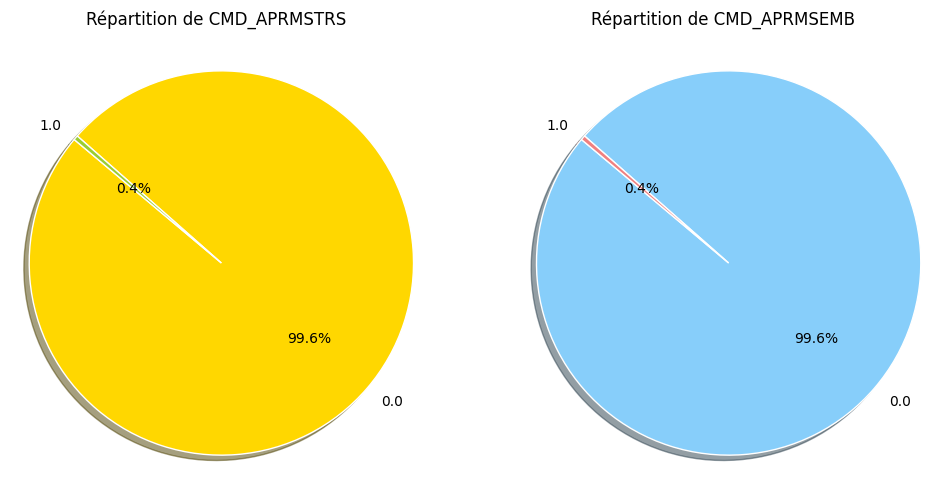

In [ ]:
import matplotlib.pyplot as plt

# Graphique de gauche
labels = DSEC.CMD_APRMSTRS.value_counts().index
sizes = DSEC.CMD_APRMSTRS.value_counts().values
colors = ['gold', 'yellowgreen']

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))  # Création d'une figure avec deux sous-graphiques
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140, wedgeprops={"edgecolor":"white"})
ax1.axis('equal')
ax1.set_title("Répartition de CMD_APRMSTRS  ")

# Graphique de droite
labels = DSEC.CMD_APRMSEMB.value_counts().index
sizes = DSEC.CMD_APRMSEMB.value_counts().values
colors = ['lightskyblue', 'lightcoral']

ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140, wedgeprops={"edgecolor":"white"})
ax2.axis('equal')
ax2.set_title("Répartition de CMD_APRMSEMB  ")

plt.show()

# interpritation :


*   CMD_APRMSEMB (Applique la remise sur Cout d'Emballage)

*   CMD_APRMSTRS (Applique la remise sur Cout de Transport)

* On remarque que seulement 0.4% des commandes qui sont benificiées des remises des couts d'emballage et cout de transport

In [ ]:
DSEC1.columns
print(DSEC1.shape)
print(DSEC.shape)

(42777, 23)
(3265, 41)


In [ ]:
## Jointre les deux table DSEC et DSEC1 car il ya des colonnes importantes dans DSEC1 tel que la quantité et l'unité de mesure
DSEC_merged = DSEC1.merge(DSEC, on='CMD_NUM', how='left')
DSEC_merged

,CMD_NUM,LCMD_ITEM,AUT_CODE,AOF_OFF_NUM,LOT_NUM,LLOT_LIG_NUM,LCMD_DESIGN,LCMD_TYPE,LCMD_POSITION,LCMD_UNITE,...,CMD_OBSRANNUL,DIVER_TAXE,LIB_DIVERTAXE,CMD_LIBEMBALLAGE,CMD_TYPELIVR,CMD_DATEACCUSE,CMD_ETAT,CMD_APRMSTRS,CMD_APRMSEMB,REMISE
0,AK635/A,1,NaN,SH-DP-AT/013/13/M,1.0,1.0,UN CAMION GRUE AVEC TREUIL 1.5 TONNES,NaN,NaN,P,...,NaN,NaN,NaN,NaN,M,NaN,NaN,0.0,0.0,NaN
1,AK697/A,1,NaN,A10-DP-AT-044,1.0,1.0,GAS-OIL,NaN,NaN,L,...,NaN,NaN,NaN,NaN,M,NaN,NaN,0.0,0.0,NaN
2,AK698/A,1,NaN,A10-DP-AT-044,1.0,3.0,ESSENCE SANS PLOMB 95,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,M,NaN,NaN,0.0,0.0,NaN
3,AK733/A,1,NaN,AK733/A,1.0,1.0,GAS OIL,NaN,NaN,HL,...,NaN,NaN,NaN,NaN,M,NaN,NaN,0.0,0.0,NaN
4,AK734/A,1,NaN,A10-DP-AT-044,1.0,3.0,ESSENCE SANS PLOMB,NaN,NaN,HL,...,NaN,NaN,NaN,NaN,M,NaN,NaN,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42772,ZY279/A,1,NaN,CF-SH-EP-DP-AT-011-21-M,1.0,1.0,Puits : TOT 7 pompe à balanciers complète TYPE...,NaN,NaN,P,...,NaN,NaN,NaN,NaN,M,NaN,NaN,0.0,0.0,NaN
42773,ZY279/A,2,NaN,CF-SH-EP-DP-AT-011-21-M,1.0,2.0,Puits : TOT 8 pompe à balanciers complète TYPE...,NaN,NaN,P,...,NaN,NaN,NaN,NaN,M,NaN,NaN,0.0,0.0,NaN
42774,ZY279/A,3,NaN,CF-SH-EP-DP-AT-011-21-M,1.0,3.0,Puits : TOT 9 pompe à balanciers complète TYPE...,NaN,NaN,P,...,NaN,NaN,NaN,NaN,M,NaN,NaN,0.0,0.0,NaN
42775,ZY286/A,1,NaN,CF/SH-EP-DP-AT/04/20/P,1.0,1.0,ECHANGEUR DE CHALEUR GAZ/GAZ E102,NaN,NaN,P,...,NaN,NaN,NaN,NaN,M,NaN,NaN,0.0,0.0,NaN


In [ ]:
## Comparaison entre les colonnes
print(DSEC_merged.shape)
print(DSEC.shape)
print(DSEC1.shape)
print(DSEC_merged.columns)
print(DSEC.columns)
print(DSEC1.columns)
print(DSEC_merged.dtypes)
DSEC_merged.isnull().sum()
percent_missing = DSEC_merged.isnull().sum() * 100 / len(DSEC_merged)
null_percentage_sorted = percent_missing.sort_values(ascending=False)
print(percent_missing)

(42777, 63)
(3265, 41)
(42777, 23)
Index(['CMD_NUM', 'LCMD_ITEM', 'AUT_CODE', 'AOF_OFF_NUM', 'LOT_NUM',
       'LLOT_LIG_NUM', 'LCMD_DESIGN', 'LCMD_TYPE', 'LCMD_POSITION',
       'LCMD_UNITE', 'LCMD_QUANTITE', 'LCMD_QUANTAFFECT', 'LCMD_PRIX_UNIT',
       'LCMD_TAXE', 'LCMD_TRAD', 'LCMD_LIGNE', 'LCMD_CODIF', 'LCMD_ANNULER',
       'LCMD_TITRE', 'LCMD_LG', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22',
       'CMD_ALIAS', 'FOU_CODE', 'CTR_NUM', 'CMD_DATE', 'CMD_SUIVI',
       'CMD_CONSULTATION', 'CMD_REFERENCE', 'CMD_FACTURE', 'CMD_REGLEMENT',
       'CMD_DELAIACHAT', 'CMD_EMBALLAGE', 'CMD_MODLIEULIV', 'CMD_CLAUSE',
       'CMD_OBSERVATION', 'CMD_TRANSPORT', 'CMD_DATEPOSIT', 'CMD_TAXE',
       'CMD_VALTAXE', 'CMD_INC', 'CMD_MONNAIE', 'CMD_PAI_TYPE', 'CMD_RETENUE',
       'CMD_REMISE', 'CMD_TIMBRE', 'CMD_AVENANT', 'CMD_ARH', 'CMD_DELAICMD',
       'CMD_TUAR', 'CMD_ADIRECT', 'CMD_ANNULER', 'CMD_OBSRANNUL', 'DIVER_TAXE',
       'LIB_DIVERTAXE', 'CMD_LIBEMBALLAGE', 'CMD_TYPELIVR', 'CMD_DATEACC

In [ ]:
## visualisation des pourcentage des valeurs manquantes après la fusion des deux tables
fig = px.bar(x=null_percentage_sorted.index, y=null_percentage_sorted.values,
             labels={'x': 'Nom-colonnes', 'y': 'Pourcentage_valeurs_manquantes'}, width=600, height=400)
fig.show()

Interpritation :    
* Les colonnes qui ont plus de 98% des valeurs manquantes sont augmentées augmenté apres la fusion

In [ ]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# Récupérer les fréquences de CMD_SUIVI et CMD_TAXE
freq_s = DSEC_merged['CMD_SUIVI'].value_counts().sort_values(ascending=False)
freq_t = DSEC_merged['CMD_TAXE'].value_counts().sort_values(ascending=False)

# Créer une figure avec deux sous-figures
fig = make_subplots(rows=1, cols=2)

# Ajouter une barre de fréquence pour CMD_SUIVI dans la première sous-figure
fig.add_trace(go.Bar(x=freq_s.index, y=freq_s.values, marker_color='#63290A'), row=1, col=1)
fig.update_xaxes(title_text="LCMD_SUIVI", row=1, col=1, range=[-0.5, 13]) ## Afichage seulement des 14 premiers
fig.update_yaxes(title_text="Count", row=1, col=1)
# Ajouter une barre de fréquence pour CMD_TAXE dans la deuxième sous-figure
fig.add_trace(go.Bar(x=freq_t.index, y=freq_t.values, marker_color='#0A6322'), row=1, col=2)
fig.update_xaxes(title_text="LCMD_TAXE", row=1, col=2)
fig.update_yaxes(title_text="Count", row=1, col=2)
# Définir la taille de la figure
fig.update_layout(width=800, height=400)

# Afficher la figure
fig.show()

# Interpritation :    
* D'un point de vu ligne de commandes le service ordonnancement qui est chargé de suivi a perdu sa place en terme de nombre des lignes de commande suivis
* La majorité des taxe des lignes de commande sont de type H

In [ ]:
freq_e = DSEC_merged['CMD_ANNULER'].value_counts().sort_values(ascending=False)
freq_u = DSEC_merged['CMD_MODLIEULIV'].value_counts().sort_values(ascending=False)
# Créer une figure avec deux sous-figures
fig = make_subplots(rows=1, cols=2)
# Ajouter une barre de fréquence pour CMD_ANNULER dans la troisieme sous-figure
fig.add_trace(go.Bar(x=freq_e.index, y=freq_e.values, marker_color='#0A6322'), row=1, col=1)
fig.update_xaxes(title_text="LCMD_ANNULER", row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=1)
# Ajouter une barre de fréquence pour CMD_MODLIEULIV dans la deuxième sous-figure
fig.add_trace(go.Bar(x=freq_u.index, y=freq_u.values, marker_color='#0A6322'), row=1, col=2)
fig.update_xaxes(title_text="LCMD_MODLIEULIV", row=1, col=2, range=[-0.5, 13])
fig.update_yaxes(title_text="Count", row=1, col=2)
# Définir la taille de la figure
fig.update_layout(width=1000, height=400)

# Afficher la figure
fig.show()

# Interpritation :    
* Presque 100% des lignes de commandes ne sont pas annuler
* La majorité des lieu de livraison des ligne de commandes sont a travers le port de mostaganem , alger et aeroport d'alger .

In [ ]:
freq_z = DSEC_merged['CMD_DELAICMD'].value_counts().sort_values(ascending=False)
freq_v = DSEC_merged['CMD_TYPELIVR'].value_counts().sort_values(ascending=False)
# Créer une figure avec deux sous-figures
fig = make_subplots(rows=1, cols=2)
# Ajouter une barre de fréquence pour CMD_DELAICMD dans la deuxième sous-figure
fig.add_trace(go.Bar(x=freq_z.index, y=freq_z.values, marker_color='#0A6322'), row=1, col=1)
fig.update_xaxes(title_text="LCMD_DELAICMD", row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=1)
# Ajouter une barre de fréquence pour CMD_DELAICMD dans la deuxième sous-figure
fig.add_trace(go.Bar(x=freq_v.index, y=freq_v.values, marker_color='#0A6322'), row=1, col=2)
fig.update_xaxes(title_text="LCMD_TYPELIVR", row=1, col=2)
fig.update_yaxes(title_text="Count", row=1, col=2)
# Définir la taille de la figure
fig.update_layout(width=1000, height=400)

# Afficher la figure
fig.show()

# Interpritation :    
* 98% des delai des lignes de  commandes ne sont pas respectés
* 42 000 lignes de commandes sont livrés par des mois

In [ ]:
freq_z = DSEC_merged['FOU_CODE'].value_counts().sort_values(ascending=False)
freq_v = DSEC_merged['LCMD_UNITE'].value_counts().sort_values(ascending=False)
freq_k = DSEC_merged['CMD_AVENANT'].value_counts().sort_values(ascending=False)
# Créer une figure avec deux sous-figures
fig = make_subplots(rows=2, cols=2)
# Ajouter une barre de fréquence pour CMD_DELAICMD dans la deuxième sous-figure
fig.add_trace(go.Bar(x=freq_z.index, y=freq_z.values, marker_color='#0A6322'), row=1, col=1)
fig.update_xaxes(title_text="FOU_CODE", row=1, col=1, range=[-0.5, 13])
fig.update_yaxes(title_text="Count", row=1, col=1)
# Ajouter une barre de fréquence pour CMD_DELAICMD dans la deuxième sous-figure
fig.add_trace(go.Bar(x=freq_v.index, y=freq_v.values, marker_color='#0A6322'), row=1, col=2)
fig.update_xaxes(title_text="LCMD_UNITE", row=1, col=2, range=[-0.5, 13])
fig.update_yaxes(title_text="Count", row=1, col=2)
# Ajouter une barre de fréquence pour CMD_AVENANT dans la deuxième sous-figure
fig.add_trace(go.Bar(x=freq_k.index, y=freq_k.values, marker_color='#0A6322'), row=2, col=1)
fig.update_xaxes(title_text="CMD_AVENANT (probleme exeptionnel) ", row=2, col=1)
fig.update_yaxes(title_text="Count", row=2, col=1)
# Définir la taille de la figure
fig.update_layout(width=1000, height=400)

# Afficher la figure
fig.show()

Interpritation :    
* La majorité des lignes de commandes ont un avenant de type 1 et 2
*  

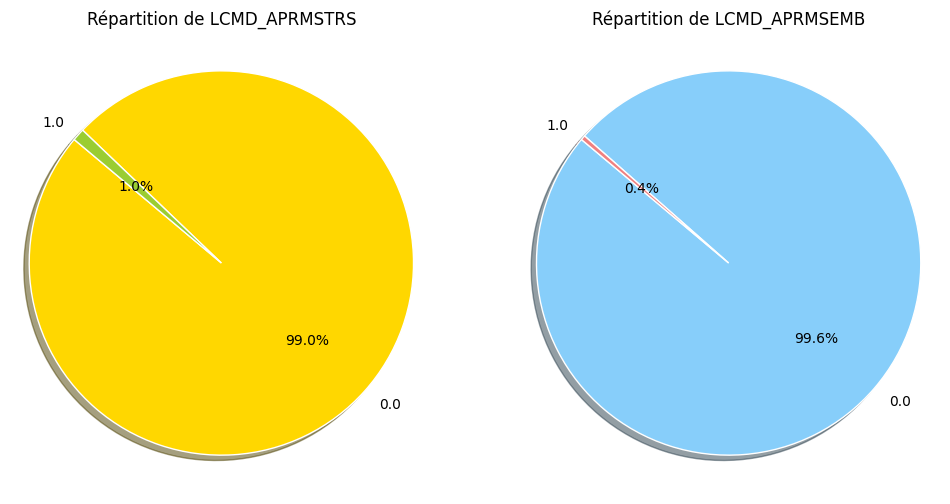

In [ ]:
import matplotlib.pyplot as plt

# Graphique de gauche
labels = DSEC_merged.CMD_APRMSTRS.value_counts().index
sizes = DSEC_merged.CMD_APRMSTRS.value_counts().values
colors = ['gold', 'yellowgreen']

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))  # Création d'une figure avec deux sous-graphiques
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140, wedgeprops={"edgecolor":"white"})
ax1.axis('equal')
ax1.set_title("Répartition de LCMD_APRMSTRS")

# Graphique de droite
labels = DSEC.CMD_APRMSEMB.value_counts().index
sizes = DSEC.CMD_APRMSEMB.value_counts().values
colors = ['lightskyblue', 'lightcoral']

ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140, wedgeprops={"edgecolor":"white"})
ax2.axis('equal')
ax2.set_title("Répartition de LCMD_APRMSEMB")

plt.show()

# Interpritation :    
* Par lignes de commandes , 99% des lignes  ne sont pas benificier d'une remise des couts d'emballage et couts de transport

# Data preprocessing

In [ ]:
## Supprimer les lignes des valeurs manquantes pour notre cible Lead_time_d'achat
DSEC_merged.dropna(subset=['CMD_DELAIACHAT'], inplace=True)
DSEC_merged.isnull().sum()

CMD_NUM               0
LCMD_ITEM             0
AUT_CODE          33394
AOF_OFF_NUM        1720
LOT_NUM            1910
                  ...  
CMD_DATEACCUSE    33416
CMD_ETAT          33416
CMD_APRMSTRS       1261
CMD_APRMSEMB       1261
REMISE            32642
Length: 63, dtype: int64

In [ ]:
## Voir les valeurs aberrantes des lead times avant quelle seront transformer en une seule unité (mois)
import plotly.express as px
fig = px.box(DSEC_merged, y='CMD_DELAIACHAT', width=600, height=400)
fig.show()

# Interpritation :    
* Ca se voit q'uil existe pas mal des valeurs aberrantes qui influences sur la precision de modele

In [ ]:
## Voir la distrubution des lead times avant quelle seront transformer en une seule unité (mois)
import plotly.figure_factory as ff
fig = ff.create_distplot([DSEC_merged['CMD_DELAIACHAT']], ['CMD_DELAIACHAT'], show_hist=False)
fig.update_layout(width=600, height=400)
fig.show()

# Interpritation :    
* La distribution de notre target est asymetrique ainsi que ne suit pas une distribution normale

In [ ]:
DSEC['CMD_TYPELIVR'].value_counts()

M    3100
S     102
J      63
Name: CMD_TYPELIVR, dtype: int64

In [ ]:
## Transformation de lead time en une seule unité ( mois )
DSEC_merged.loc[DSEC_merged['CMD_TYPELIVR'] == 'J', 'CMD_DELAIACHAT'] = DSEC_merged.loc[DSEC_merged['CMD_TYPELIVR'] == 'J', 'CMD_DELAIACHAT'] / 30
DSEC_merged.loc[DSEC_merged['CMD_TYPELIVR'] == 'S', 'CMD_DELAIACHAT'] = DSEC_merged.loc[DSEC_merged['CMD_TYPELIVR'] == 'S', 'CMD_DELAIACHAT'] / 4
DSEC_merged[DSEC_merged['CMD_TYPELIVR']=="J"]['CMD_DELAIACHAT']
DSEC_merged.loc[DSEC_merged['CMD_TYPELIVR'] == 'S', 'CMD_DELAIACHAT']
DSEC_merged['CMD_TYPELIVR'] = DSEC_merged['CMD_TYPELIVR'].replace('J', 'M')
DSEC_merged['CMD_TYPELIVR'] = DSEC_merged['CMD_TYPELIVR'].replace('S', 'M')

In [ ]:
!pip uninstall scipy -y
!pip uninstall pingouin -y
!pip install pingouin

Found existing installation: scipy 1.10.1
Uninstalling scipy-1.10.1:
  Successfully uninstalled scipy-1.10.1
Found existing installation: pingouin 0.5.3
Uninstalling pingouin-0.5.3:
  Successfully uninstalled pingouin-0.5.3
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Using cached pingouin-0.5.3-py3-none-any.whl (198 kB)
  Using cached scipy-1.10.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (34.4 MB)


In [ ]:
## Suprission des outliers
mean = DSEC_merged['CMD_DELAIACHAT'].mean()
std = DSEC_merged['CMD_DELAIACHAT'].std()
lower_bound = mean - 3 * std
upper_bound = mean + 3 * std
DSEC_merged = DSEC_merged[(DSEC_merged['CMD_DELAIACHAT'] > lower_bound) & (DSEC_merged['CMD_DELAIACHAT'] < upper_bound)]
DSEC_merged.shape
DSEC_merged['CMD_DATE'].shape
## supprission des valeurs manquantes pour les deux colonnes CMD_DATE et CMD_TRANSPORT
DSEC_merged.dropna(subset=['CMD_DATE'], inplace=True)
DSEC_merged.dropna(subset=['CMD_TRANSPORT'], inplace=True)
DSEC_merged.shape
DSEC_merged.columns
fig = ff.create_distplot([DSEC_merged['CMD_DELAIACHAT']], ['CMD___livraison'], show_hist=False, colors=['red', 'lightgray'])
fig.update_layout(width=600, height=400)
fig.show()
print(DSEC_merged['CMD_DELAIACHAT'].mean())
print(DSEC_merged['CMD_DELAIACHAT'].median())
print(DSEC_merged['CMD_DELAIACHAT'].mode())

12.516484825384726
12.0
0    12.0
Name: CMD_DELAIACHAT, dtype: float64


In [ ]:
DSEC_merged.shape

(20989, 63)

# Interpritation :    
* Apres la supprission des valeurs aberrantes et d'apres la nouvelle visualisation de la distribution , on peut dire que notre variable cible suit approximativement une loi normale

In [ ]:
## utilisant le test de Kruskal-Wallis. L'indice de l'effet taille est une mesure de la taille de l'effet d'une variable indépendante sur la variable dépendante,
##Plus l'indice est élevé, plus l'effet de la variable indépendante est important
# colonnes indépendantes
import pingouin as pg
independents = ['CMD_NUM', 'LCMD_ITEM', 'AUT_CODE', 'AOF_OFF_NUM', 'LOT_NUM',
       'LLOT_LIG_NUM', 'LCMD_DESIGN', 'LCMD_TYPE', 'LCMD_POSITION',
       'LCMD_UNITE', 'LCMD_QUANTITE', 'LCMD_QUANTAFFECT', 'LCMD_PRIX_UNIT',
       'LCMD_TAXE', 'LCMD_TRAD', 'LCMD_LIGNE', 'LCMD_CODIF', 'LCMD_ANNULER',
       'LCMD_TITRE', 'LCMD_LG',
       'FOU_CODE', 'CTR_NUM', 'CMD_SUIVI',
       'CMD_CONSULTATION', 'CMD_REGLEMENT',
       'CMD_EMBALLAGE', 'CMD_MODLIEULIV', 'CMD_CLAUSE',
       'CMD_OBSERVATION', 'CMD_TRANSPORT', 'CMD_TAXE',
       'CMD_VALTAXE', 'CMD_INC', 'CMD_MONNAIE', 'CMD_PAI_TYPE', 'CMD_RETENUE',
       'CMD_REMISE', 'CMD_AVENANT', 'CMD_ARH', 'CMD_DELAICMD',
       'CMD_TUAR', 'CMD_ADIRECT', 'CMD_ANNULER', 'CMD_OBSRANNUL', 'DIVER_TAXE',
       'LIB_DIVERTAXE', 'CMD_LIBEMBALLAGE', 'CMD_TYPELIVR',
       'CMD_APRMSTRS', 'CMD_APRMSEMB', 'REMISE']

# initialiser un dictionnaire pour stocker les résultats
results = {}

# boucle pour parcourir chaque colonne indépendante et calculer eta_sq
for column in independents:
    # calculer le test de Kruskal-Wallis
    test = pg.kruskal(data=DSEC_merged, dv='CMD_DELAIACHAT', between=column)

    # calculer eta_sq
    h = test['H']
    ddof1 = test['ddof1']
    eta_sq = h / (h + ddof1)

    # stocker les résultats dans le dictionnaire
    results[column] = eta_sq

# afficher les résultats
print(results)

{'CMD_NUM': Kruskal    0.980427
dtype: float64, 'LCMD_ITEM': Kruskal    0.139556
dtype: float64, 'AUT_CODE': Kruskal   NaN
dtype: float64, 'AOF_OFF_NUM': Kruskal    0.986908
dtype: float64, 'LOT_NUM': Kruskal    0.986688
dtype: float64, 'LLOT_LIG_NUM': Kruskal    0.31425
dtype: float64, 'LCMD_DESIGN': Kruskal    0.530132
dtype: float64, 'LCMD_TYPE': Kruskal    0.274881
dtype: float64, 'LCMD_POSITION': Kruskal    0.874581
dtype: float64, 'LCMD_UNITE': Kruskal    0.546297
dtype: float64, 'LCMD_QUANTITE': Kruskal    0.756975
dtype: float64, 'LCMD_QUANTAFFECT': Kruskal   NaN
dtype: float64, 'LCMD_PRIX_UNIT': Kruskal    0.597991
dtype: float64, 'LCMD_TAXE': Kruskal    0.0
dtype: float64, 'LCMD_TRAD': Kruskal    0.571429
dtype: float64, 'LCMD_LIGNE': Kruskal   NaN
dtype: float64, 'LCMD_CODIF': Kruskal    0.525933
dtype: float64, 'LCMD_ANNULER': Kruskal    0.869014
dtype: float64, 'LCMD_TITRE': Kruskal    0.024042
dtype: float64, 'LCMD_LG': Kruskal    0.151778
dtype: float64, 'FOU_CODE': Krus

In [ ]:
##Supprission des colonnes
percent_missing = DSEC_merged.isnull().sum() * 100 / len(DSEC_merged)
keep_cols = ['CMD_AVENANT']
drop_cols = [col for col in percent_missing.index if percent_missing[col] > 90 and col not in keep_cols]
DSEC_merged.drop(columns=drop_cols, inplace = True)
DSEC_merged.columns
## laisser les columns les plus pertinants ( test stat de Kruskal-Wallis)
DSEC_merged.drop(columns=['CMD_NUM', 'LCMD_ITEM', 'LLOT_LIG_NUM', 'LCMD_CODIF', 'LCMD_TITRE', 'CMD_REFERENCE', 'LCMD_DESIGN', 'CMD_TYPELIVR', 'LCMD_ANNULER', 'CMD_CONSULTATION', 'CMD_VALTAXE', 'CMD_TAXE', 'CMD_DELAICMD'], inplace = True)
DSEC_merged.columns

Index(['LOT_NUM', 'LCMD_UNITE', 'LCMD_QUANTITE', 'LCMD_PRIX_UNIT', 'FOU_CODE',
       'CMD_DATE', 'CMD_SUIVI', 'CMD_REGLEMENT', 'CMD_DELAIACHAT',
       'CMD_EMBALLAGE', 'CMD_MODLIEULIV', 'CMD_TRANSPORT', 'CMD_MONNAIE',
       'CMD_PAI_TYPE', 'CMD_AVENANT', 'CMD_ADIRECT', 'CMD_ANNULER',
       'CMD_APRMSTRS', 'CMD_APRMSEMB'],
      dtype='object')

In [ ]:
## visualisation des valeurs manquantes en pourcentage
percent_missing = DSEC_merged.isnull().sum() * 100 / len(DSEC_merged)
null_percentage_sorted = percent_missing.sort_values(ascending=False)
fig = px.bar(x=null_percentage_sorted.index, y=null_percentage_sorted.values,
             labels={'x': 'Colonnes', 'y': 'Pourcentage de valeurs manquantes'}, width=600, height=400)
fig.show()

In [ ]:
## remplacer les valeurs manquantes
import numpy as np
DSEC_merged['CMD_AVENANT'].value_counts()
DSEC_merged['CMD_AVENANT'].fillna(0, inplace=True)
DSEC_merged['CMD_MONNAIE'].value_counts()
DSEC_merged['CMD_MONNAIE'].fillna('Non specifier', inplace=True)
DSEC_merged['CMD_TRANSPORT'].value_counts()
DSEC_merged['CMD_TRANSPORT'].fillna(DSEC_merged['CMD_TRANSPORT'].median(), inplace=True)
DSEC_merged['CMD_EMBALLAGE'].value_counts()
DSEC_merged['CMD_EMBALLAGE'].fillna(DSEC_merged['CMD_EMBALLAGE'].median(), inplace=True)
DSEC_merged['LCMD_UNITE'].value_counts()
DSEC_merged['LCMD_UNITE'].fillna('Non specifier', inplace=True)
DSEC_merged['CMD_ADIRECT'].value_counts()
DSEC_merged['CMD_ADIRECT'].fillna(-1, inplace=True)
DSEC_merged['CMD_MODLIEULIV'].value_counts()
DSEC_merged['CMD_MODLIEULIV'].fillna('Non specifier', inplace=True)
DSEC_merged['AOF_OFF_NUM'].value_counts()
DSEC_merged['AOF_OFF_NUM'].fillna('Non specifier', inplace=True)
DSEC_merged['CTR_NUM'].value_counts()
DSEC_merged['CTR_NUM'].fillna('Non specifier', inplace=True)
DSEC_merged['CMD_APRMSTRS'].value_counts()
DSEC_merged['CMD_APRMSTRS'].fillna(-1, inplace=True)
DSEC_merged['CMD_APRMSEMB'].value_counts()
DSEC_merged['CMD_APRMSEMB'].fillna(-1, inplace=True)
DSEC_merged['CMD_REGLEMENT'].value_counts()
DSEC_merged['CMD_REGLEMENT'].fillna('Non specifier', inplace=True)

DSEC_merged['CMD_PAI_TYPE'].value_counts()
DSEC_merged['CMD_PAI_TYPE'].fillna('Non specifier', inplace=True)
DSEC_merged['LCMD_QUANTITE'].value_counts()
DSEC_merged['LCMD_QUANTITE'].fillna(-1, inplace=True)
DSEC_merged['LCMD_PRIX_UNIT'] = DSEC_merged['LCMD_PRIX_UNIT'].replace('P', np.nan)
DSEC_merged['LCMD_PRIX_UNIT'].mean()
DSEC_merged['LCMD_PRIX_UNIT'].fillna(DSEC_merged['LCMD_PRIX_UNIT'].median(), inplace=True)
DSEC_merged['CMD_APRMSEMB'].value_counts()
DSEC_merged['LOT_NUM'].fillna(DSEC_merged['LOT_NUM'].mean(), inplace=True)
DSEC_merged.dtypes

KeyError: ignored

In [ ]:
## Encoder les variables categorielles
from sklearn.preprocessing import LabelEncoder

## Transformation des données
from sklearn.preprocessing import StandardScaler
import numpy as np

DSEC_merged['CMD_DATE'] = pd.to_datetime(DSEC_merged['CMD_DATE'], format='%Y-%m-%d %H:%M:%S')
# Définir l'époque UNIX comme référence
epoch = np.datetime64('1970-01-01')

# Convertir les dates en nombres de secondes depuis l'époque
DSEC_merged['CMD_DATE'] = (DSEC_merged['CMD_DATE'] - epoch) / np.timedelta64(1, 's')

# Convertir la colonne CMD_DATE en int64
DSEC_merged['CMD_DATE'] = DSEC_merged['CMD_DATE'].astype('float64')
# afficher le nouveau DataFrame encodé

## Voir la correlation
plt.figure(figsize=(10,6))
sns.heatmap(DSEC_merged.corr(), annot=True)
plt.show()
DSEC_merged.columns
for col in DSEC_merged.columns:
    # si la colonne est de type object
    if DSEC_merged[col].dtype == 'object':
        # encoder la colonne
        encoder = LabelEncoder()
        DSEC_merged[col] = encoder.fit_transform(DSEC_merged[col].astype(str))
x = DSEC_merged.drop(['CMD_DELAIACHAT'], axis=1)
y = DSEC_merged['CMD_DELAIACHAT']
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=(DSEC_merged.drop('CMD_DELAIACHAT', axis=1)).columns)

# Interpritation :     
* D'apres le heatmap on peut dire quil n'existe pas une forte correlation entre target et les autres features

In [ ]:
## Appliquer PCA pour la reduction des dimenstionalités
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

# Modelisation

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
y = np.array(y).reshape(-1,1)
# Train our model
x_train,x_test,y_train,y_test = train_test_split(x_pca,y,test_size=0.20,random_state=2)

In [ ]:
## application de RandomizedSearchCV pour trouver les meilleur hyperparametres pour le modele KNN .
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import learning_curve
# Diviser les données en ensembles de formation et de test
pca = PCA(n_components=10)
x_pca = pca.fit_transform(x_scaled)
X_train, X_test, y_train, y_test = train_test_split(x_pca,y, test_size=0.2, random_state=42)

# Initialiser le modèle KNN
knn = KNeighborsRegressor()

# Créer une grille de recherche des hyperparamètres
param_dist = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Créer un objet RandomizedSearchCV
random_search = RandomizedSearchCV(
    knn, param_distributions=param_dist, n_iter=10, cv=5, n_jobs=-1, random_state=42)

# Entraîner le modèle avec RandomizedSearchCV
random_search.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test avec le meilleur modèle trouvé
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

# Évaluer les performances du modèle
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("R² score pour KNN est:", r2)
# calculate RMSE
rmse = mean_squared_error(y_test, y_pred, squared=False)
# calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print("RMSE pour KNN est :", rmse)
print("MAE pour KNN est :", mae)
# Afficher les meilleurs hyperparamètres trouvés
print("Best hyperparameters:", random_search.best_params_)
# Définition de la fonction pour tracer les courbes d'apprentissage
def plot_learning_curves(model, X, y):
    train_sizes, train_scores, test_scores = learning_curve(model, X, y, cv=5, scoring='r2', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10))
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.plot(train_sizes, train_mean, label='Training score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
    plt.plot(train_sizes, test_mean, label='Cross-validation score')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
    plt.xlabel('Training set size')
    plt.ylabel('R2 score')
    plt.title('Learning curves')
    plt.legend()

# Tracer les courbes d'apprentissage pour le modèle choisi
plot_learning_curves(knn, X_train, y_train)
plt.show()

Meilleurs hyperparamètres : {'learning_rate': 0.5, 'max_depth': 5, 'min_child_samples': 16, 'n_estimators': 1230, 'num_leaves': 9, 'reg_alpha': 0.01, 'reg_lambda': 2.0}
R2 score pour LGBM: 0.92
RMSE pour LGBM : 1.59
MAE pour LGBM : 0.61


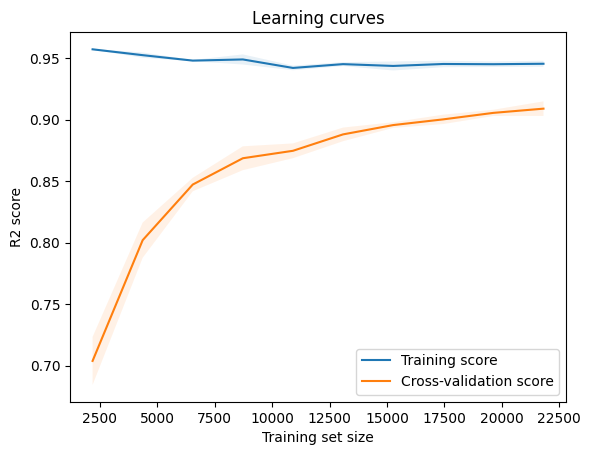

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
x_train,x_test,y_train,y_test = train_test_split(x_pca,y,test_size=0.17,random_state=2)
# Création d'un dictionnaire pour les hyperparamètres à tester
param_dist = {'n_estimators': sp_randint(100, 2000),
              'max_depth': sp_randint(2, 18),
              'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 1, 0.04, 0.03, 0.02, 0.00001],
              'num_leaves': sp_randint(2, 50),
              'min_child_samples': sp_randint(2, 30),
              'reg_alpha': [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20, 100, 1000, 200, 150, 0.01, 0.001, 0.02, 0.002],
              'reg_lambda': [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 0.01, 0.001]}

# Création du modèle avec régularisation
model_l = LGBMRegressor(random_state=42, reg_alpha=0.01, reg_lambda=0.1)

# Recherche des hyperparamètres optimaux
random_search = RandomizedSearchCV(model_l, param_distributions=param_dist, n_iter=10, cv=5, random_state=42)

# Entraînement du modèle avec les meilleurs hyperparamètres trouvés
random_search.fit(x_train, y_train)

# Prédiction sur les données de test
y_pred = random_search.predict(x_test)

# Calcul du R2 score et du RMSE sur les données de test
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)

print("Meilleurs hyperparamètres : {}".format(random_search.best_params_))
print("R2 score pour LGBM: {:.2f}".format(r2))
print("RMSE pour LGBM : {:.2f}".format(rmse))
print("MAE pour LGBM : {:.2f}".format(mae))
plot_learning_curves(random_search.best_estimator_, x_train, y_train)
plt.show()

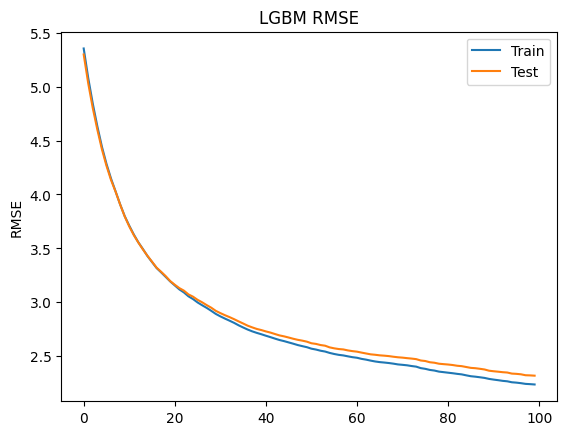

In [ ]:
# Entraînement du modèle sur l'ensemble des données d'entraînement en spécifiant les données d'évaluation
eval_set = [(x_train, y_train), (x_test, y_test)]
model_l.fit(x_train, y_train, eval_set=eval_set, eval_metric='rmse', verbose=False)

# Affichage de la courbe de perte
results = model_l.evals_result_
train_loss = results['training']['rmse']
test_loss = results['valid_1']['rmse']
epochs = len(train_loss)
x_axis = range(0, epochs)
fig, ax = plt.subplots()
ax.plot(x_axis, train_loss, label='Train')
ax.plot(x_axis, test_loss, label='Test')
ax.legend()
plt.ylabel('RMSE')
plt.title('LGBM RMSE')
plt.show()

# Interpritation :
D'après ces résultats qui représente la prediction des délais d'achat en utilisant le fameux algorithm " KNN " et l'évaluation de ce dérnier en utilisant quelques metrics ( R² , RMSE et MAE ) on peut remarquer que R² a donné un bon résultat de 0.97 et cela se voit clairement dans le graphe qui montre une coéhrence entre le training score et le cross validation score et sont proportionelle et augmente avec lee temps jusqu'a s'approche de 1

Meilleurs hyperparamètres : {'max_depth': 19, 'min_impurity_decrease': 0.0001, 'min_samples_leaf': 9, 'min_samples_split': 3}
R2 score pour DecisionTreeRegressor : 0.94
RMSE pour DecisionTreeRegressor : 1.42
MAE pour DecisionTreeRegressor : 0.38


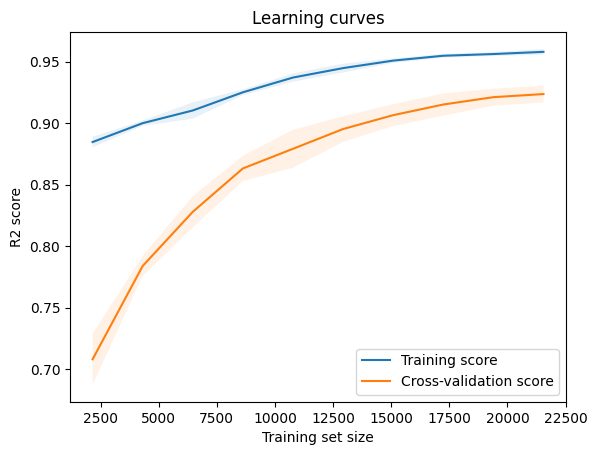

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import randint as sp_randint
pca = PCA(n_components=10)
x_pca = pca.fit_transform(x_scaled)
X_train, X_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.18, random_state=42)

# Création d'un dictionnaire pour les hyperparamètres à tester
param_dist = {'max_depth': sp_randint(2, 20),
              'min_samples_split': sp_randint(2, 20),
              'min_samples_leaf': sp_randint(1, 20),
              'min_impurity_decrease': [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.03, 0.04, 0.001, 0.0001]}

# Création du modèle
model_i = DecisionTreeRegressor(random_state=42)

# Recherche des hyperparamètres optimaux
random_search = RandomizedSearchCV(model_i, param_distributions=param_dist, n_iter=10, cv=5, random_state=42)

# Entraînement du modèle avec les meilleurs hyperparamètres trouvés
random_search.fit(X_train, y_train)

# Prédiction sur les données de test
y_pred = random_search.predict(X_test)

# Calcul du R2 score sur les données de test
r2 = r2_score(y_test, y_pred)
# Calcul du RMSE sur les données de test
rmse = mean_squared_error(y_test, y_pred, squared=False)
# Calcul du MAE sur les données de test
mae = mean_absolute_error(y_test, y_pred)

print("Meilleurs hyperparamètres : {}".format(random_search.best_params_))
print("R2 score pour DecisionTreeRegressor : {:.2f}".format(r2))
print("RMSE pour DecisionTreeRegressor : {:.2f}".format(rmse))
print("MAE pour DecisionTreeRegressor : {:.2f}".format(mae))
plot_learning_curves(random_search.best_estimator_, X_train, y_train)
plt.show()

R2 score pour la regression Polynomial est : -0.07436061252128412
RMSE pour la regression Polynomial est : 5.869892811741356
MAE pour la regression Polynomial est : 2.1213576639747105


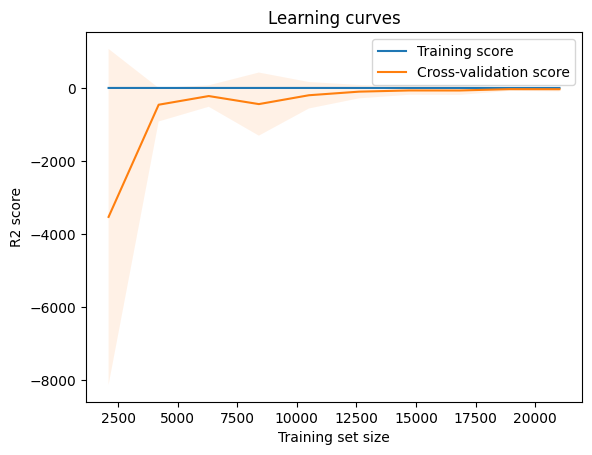

In [ ]:
## On a utiliser une boucle pour trouver le meilleure degré
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error
pca = PCA(n_components=10)
x_pca = pca.fit_transform(x_scaled)
polyfeat=PolynomialFeatures(degree=3)
x_train,x_test,y_train,y_test = train_test_split(x_pca,y,test_size=0.2,random_state=3)
xtrain_poly=polyfeat.fit_transform(x_train)
xtest_poly=polyfeat.fit_transform(x_test)
model_poly = LinearRegression()
model_poly.fit(xtrain_poly,y_train)
polypred=model_poly.predict(xtest_poly)
# calculate RMSE
rmse = mean_squared_error(y_test, polypred, squared=False)
# calculate MAE
mae = mean_absolute_error(y_test, polypred)
print("R2 score pour la regression Polynomial est :", metrics.r2_score(y_test, polypred))
print("RMSE pour la regression Polynomial est :", rmse)
print("MAE pour la regression Polynomial est :", mae)
plot_learning_curves(model_poly, xtrain_poly, y_train)
plt.show()

# Interpritation :
D'après les résultat obtenus de R² , RMSE et MAE , on peut dire que l'algoithme regression polynomial ne donne pas une bonne accuracy et cela s'affiche plus sur le graphe qui montre une stabilité nulle de training score " bleu " pendant tout l'entrainement et pour l'ensemble des donnés , et de meme pour le cross validation qui commence par des valeurs faibles et négatives et s'annule après un petit moment, donc on peut dire que c'est un underfiting car le modele n'arrive pas a connaitre bien les données d'entrainement

In [ ]:
## On a utiliser RandomizedSearchCV pour trouver ces hyperparametres
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
pca = PCA(n_components=10)
x_pca = pca.fit_transform(x_scaled)
X_train, X_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.2, random_state=42)
svm = SVR(kernel='rbf', C=1000, gamma='auto')

# Entraîner le modèlea
svm.fit(X_train, y_train)

# Tester le modèle et évaluer sa performance
y_pred = svm.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# calculate RMSE
rmse = mean_squared_error(y_test, y_pred, squared=False)
# calculate MAE
mae = mean_absolute_error(y_test, polypred)
print("R2 score pour  SVR est :", metrics.r2_score(y_test, y_pred))
print("RMSE pour SVR est :", rmse)
print("MAE pour SVR est :", mae)


R2 score pour  SVR est : 0.8992242603628176
RMSE pour SVR est : 1.8047135233515834
MAE pour SVR est : 5.677612498348142


RMSE pour RandomForestRegressor est : 1.289498135862059
MAE pour RandomForestRegressor est : 0.4391484675328248
R2 score pour RandomForestRegressor: 0.95


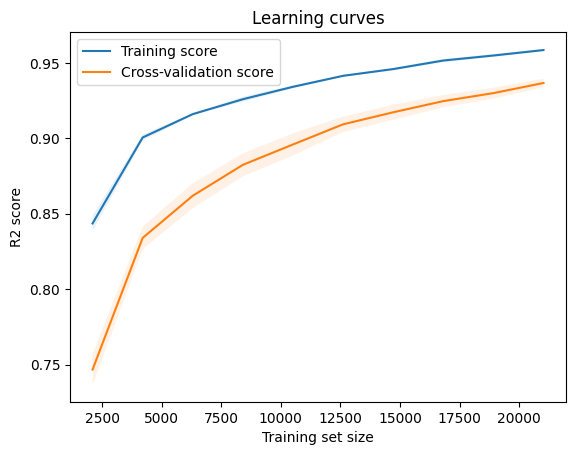

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
pca = PCA(n_components=10)
x_pca = pca.fit_transform(x_scaled)
X_train, X_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.2, random_state=42)
# Création du modèle avec les hyperparamètres choisis ( utilisation de RandomizedSearchCV )
model_r = RandomForestRegressor(n_estimators=882, max_depth=18, random_state=42, min_samples_split=17, min_samples_leaf=10)

# Entraînement du modèle sur les données d'entraînement
model_r.fit(X_train, y_train)

# Prédiction sur les données de test
y_pred = model_r.predict(X_test)

# Calcul du R2 score sur les données de test
r2 = r2_score(y_test, y_pred)
# calculate RMSE
rmse = mean_squared_error(y_test, y_pred, squared=False)
# calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print("RMSE pour RandomForestRegressor est :", rmse)
print("MAE pour RandomForestRegressor est :", mae)
print("R2 score pour RandomForestRegressor: {:.2f}".format(r2))

plot_learning_curves(model_r, X_train, y_train)
plt.show()

# Interpritation :
D'après les résultats obtenus de R² , RMSE et MAE , on remarque que cet algorithme le randomforest est très efficace et donne des résultats fiable et une accuracy forte tel qu'elle est mésuré de 0.98 pour le R² et ça se voit dans le graphe en face dont le cross validation s'augemente s'améliore avec le temps et s'approche de graphe de training score

# Interpritation :
pour interpreter ces résultat de l'entrainement de modèle de LGBM sur les données des délais d'achat on voit clairement qu'il nous a donné une meme valeur de R² avec le R.F qui est de 0.98  , sauf qu'il se diffèrent un peu sur le graph affichié dont on voit que celui training score se débute de la valeur 1 directement et cela peut représenter un overfitting et sinon pour la validation est bien  representé dont elle s'approche de plus en plus de graph de l'entrainement

On ne peut pas visualiser le graphe d'apprentissage car cela prend beaucoup de temps et nécessite un grand espace de stockage RAM.

In [ ]:
!pip install catboost
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Création du modèle ( RandomizedSearchCV pour les parametres )
model_c = CatBoostRegressor(max_depth=16, iterations=100, learning_rate=0.1)

# Entraînement du modèle sur les données d'entraînement
model_c.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=10, verbose=100)

# Prédiction sur les données de test
y_pred = model_c.predict(X_test)
# calculate RMSE
rmse = mean_squared_error(y_test, y_pred, squared=False)
# calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print("RMSE pour catboost est :", rmse)
print("MAE pour catboost est :", mae)
print("R2 score pour catboost: {:.2f}".format(r2))

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
0:	learn: 5.2593019	test: 5.2899395	best: 5.2899395 (0)	total: 5.72s	remaining: 9m 26s
99:	learn: 0.7523886	test: 1.0867109	best: 1.0867109 (99)	total: 8m 55s	remaining: 0us

bestTest = 1.086710895
bestIteration = 99

RMSE pour catboost est : 1.0867108947989708
MAE pour catboost est : 0.45409255502371065
R2 score pour catboost: 0.95


In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Création du modèle avec les hyperparamètres choisis ( RandomizedSearchCV )
model_m = MLPRegressor(hidden_layer_sizes=(88,50), activation='tanh', solver='adam', max_iter=300, random_state=42)

# Entraînement du modèle sur les données d'entraînement
model_m.fit(X_train, y_train)

# Prédiction sur les données de test
y_pred = model_m.predict(X_test)

# Calcul des métriques de performance
r2 = r2_score(y_test, y_pred)
# calculate RMSE
rmse = mean_squared_error(y_test, y_pred, squared=False)
# calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print("RMSE pour MLPRegressor est :", rmse)
print("MAE pour MLPRegressor est :", mae)
print("R2 score pour MLPRegressor: {:.2f}".format(r2))
plot_learning_curves(model_m, X_train, y_train)
plt.show()

# interpretation :
pour ces résultats qui sont obtenus après l'utilisation de MLP Regressor algorithm, on remarque qu'il nous a donnée une valeur de R² score très elevé et une basse valeur de MAE relativement et sont mesuré de 0.98 et 0.19 Respectivement ,¨POUR la representation graphique affichée on voit que les deux graphes de l'entraiement et de validation sont proportionnelle et s'augemente de plus en plus et s'approche de 1 et ça siginife qu'il donne des bonne résultats pour les prévisions par rapport aux autres algorithmes deja utilisés

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization

model_d = Sequential()
model_d.add(Dense(109, activation='tanh', input_shape=(X_train.shape[1],)))
model_d.add(BatchNormalization())  # couche de normalisation de batch
model_d.add(Dense(57, activation='tanh'))
model_d.add(BatchNormalization())  # couche de normalisation de batch
model_d.add(Dense(1))

model_d.compile(optimizer='rmsprop', loss='mean_squared_error')
history = model_d.fit(X_train, y_train, epochs=210, batch_size=55, validation_split=0.2)
y_pred = model_d.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# calculate RMSE
rmse = mean_squared_error(y_test, y_pred, squared=False)
# calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print("RMSE pour DNN est :", rmse)
print("MAE pour DNN est :", mae)
print("R2 score pour DNN: {:.2f}".format(r2))

In [ ]:
def plot_learning_curvess(history):
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title('Courbe d\'apprentissage')
    plt.ylabel('Loss')
    plt.xlabel('Epochs')
    plt.legend()
    plt.show()
plot_learning_curvess(history)

# interpritation
ces résultats sont obtenus après l'entrainement des données en utilisant un algortihme de deep learning qui le DNN et on voit que ce dernier nous a donné une meme valeur de R² qui est de 0.98 , sauf que en observant la representation graphique de loss function on remarque le graphe de train loss et celui de validation loss sont totalement identique et cela signifie clairement le phenomene d'over fitting et ça va pas donner des bons résultat pour les prévision si on obtient d'autres nouvelles données